#Làm sạch , Loại bỏ giá trị thiếu, trùng lặp, ngoại lai.

Matplotlib is building the font cache; this may take a moment.


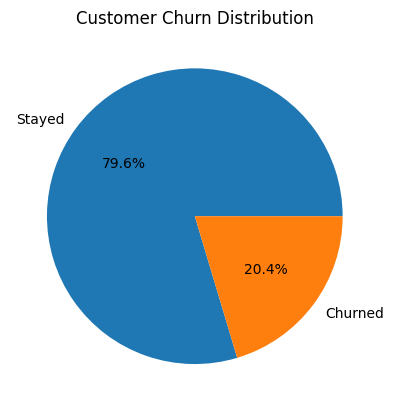

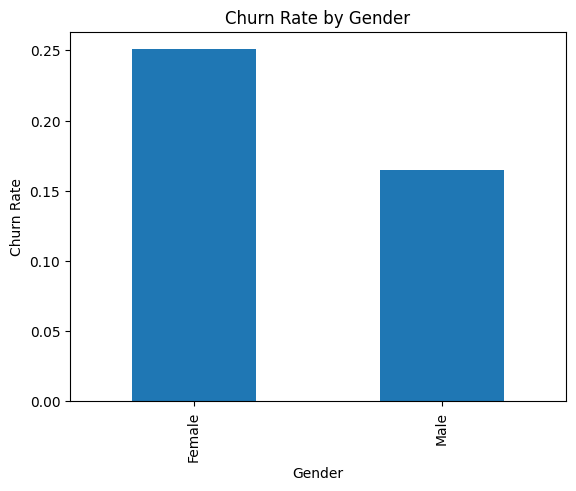

<Figure size 640x480 with 0 Axes>

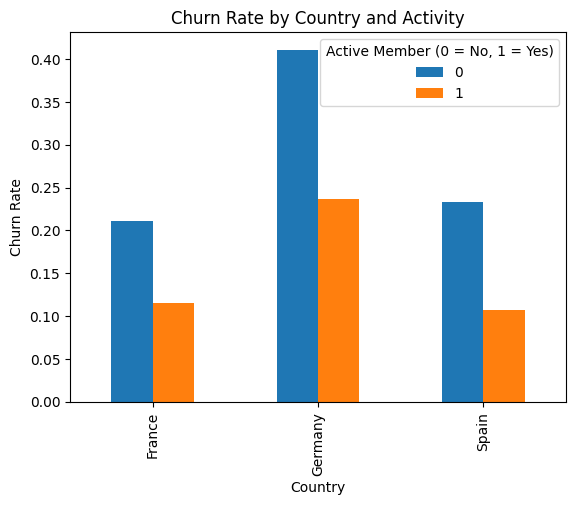

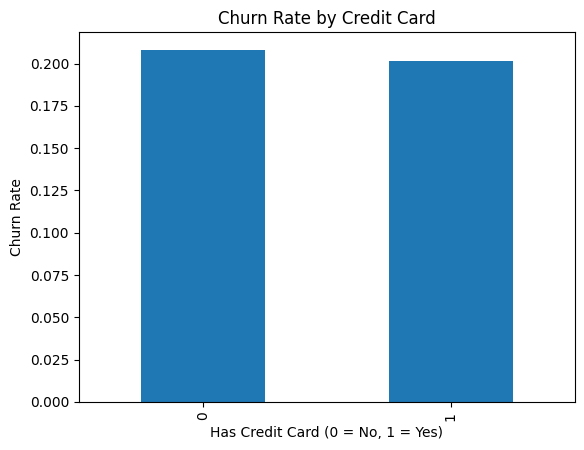

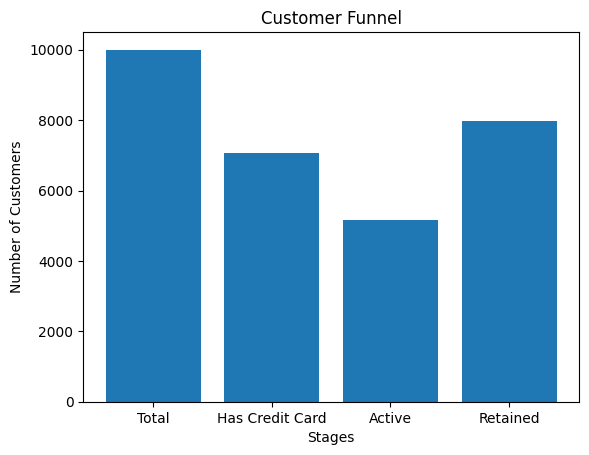


TOP NHÓM KHÁCH HÀNG CHURN CAO:
gender  country  credit_card  active_member
Female  Germany  0            0                0.448276
                 1            0                0.445652
Male    Germany  1            0                0.377729
                 0            0                0.366864
Female  Germany  0            1                0.301136
        Spain    0            0                0.295302
        Germany  1            1                0.292428
        Spain    1            0                0.291777
        France   1            0                0.270833
                 0            0                0.241692
Name: churn, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 2. BIỂU ĐỒ TRÒN (CHURN)
churn_counts = df['churn'].value_counts()

plt.figure()
plt.pie(
    churn_counts,
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%'
)
plt.title('Customer Churn Distribution')
plt.show()

# 3. BIỂU ĐỒ CỘT (GIỚI TÍNH)
gender_churn = df.groupby('gender')['churn'].mean()

plt.figure()
gender_churn.plot(kind='bar')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.show()


# 4. BIỂU ĐỒ CỘT NHÓM
# (COUNTRY + ACTIVE)
grouped = df.groupby(['country', 'active_member'])['churn'].mean().unstack()

plt.figure()
grouped.plot(kind='bar')
plt.title('Churn Rate by Country and Activity')
plt.xlabel('Country')
plt.ylabel('Churn Rate')
plt.legend(title='Active Member (0 = No, 1 = Yes)')
plt.show()


# 5. BIỂU ĐỒ CỘT NHÓM
# (CREDIT CARD)
credit_churn = df.groupby('credit_card')['churn'].mean()

plt.figure()
credit_churn.plot(kind='bar')
plt.title('Churn Rate by Credit Card')
plt.xlabel('Has Credit Card (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate')
plt.show()


# 6. BIỂU ĐỒ PHỄU (FUNNEL)
total = len(df)
has_card = df['credit_card'].sum()
active = df['active_member'].sum()
retained = (df['churn'] == 0).sum()

stages = [total, has_card, active, retained]
labels = ['Total', 'Has Credit Card', 'Active', 'Retained']

plt.figure()
plt.bar(labels, stages)
plt.title('Customer Funnel')
plt.xlabel('Stages')
plt.ylabel('Number of Customers')
plt.show()


# 7. XÁC ĐỊNH NHÓM CHURN CAO
high_risk = df.groupby(
    ['gender', 'country', 'credit_card', 'active_member']
)['churn'].mean().sort_values(ascending=False)

print("\nTOP NHÓM KHÁCH HÀNG CHURN CAO:")
print(high_risk.head(10))

In [2]:
! pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 6.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 8.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 9.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 9.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.0 MB 9.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.4/7.0 MB 8.0 MB/s eta 0:00:01
   ---------------------------- ----------- 5.0/7.0 MB 8.2 MB/s eta 0:00:01
   ------------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Viet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# làm sạch dữ liệu 

In [8]:
import pandas as pd
import numpy as np

# ======================
# 1. ĐỌC DỮ LIỆU
# ======================
df = pd.read_csv("Bank Customer Churn Prediction.csv")

print("=== 5 dòng đầu ===")
print(df.head())

print("\n=== Thông tin dữ liệu ===")
print(df.info())


# ======================
# 2. CHUẨN HÓA TÊN CỘT
# ======================
df.columns = df.columns.str.strip().str.lower()

print("\n=== CỘT SAU KHI CHUẨN HÓA ===")
print(df.columns)

# ======================
# 3. XÓA CỘT KHÔNG CẦN
# ======================
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True, errors='ignore')

print("\n=== Sau khi xóa cột ===")
print(df.head())


# ======================
# 4. KIỂM TRA MISSING
# ======================
print("\n=== Giá trị thiếu ===")
print(df.isnull().sum())

# Xử lý missing
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\n=== Sau khi xử lý missing ===")
print(df.isnull().sum())


# ======================
# 5. XÓA TRÙNG LẶP
# ======================
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"\n=== Xóa trùng: {before - after} dòng ===")


# ======================
# 6. CHUẨN HÓA TEXT
# ======================
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()

print("\n=== Sau khi chuẩn hóa text ===")
print(df.head())


# ======================
# 7. XỬ LÝ GIÁ TRỊ ÂM
# ======================
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df = df[df[col] >= 0]

print("\n=== Sau khi loại giá trị âm ===")
print(df.describe())


# ======================
# 8. XỬ LÝ OUTLIERS (IQR)
# ======================
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in numeric_cols:
    df = remove_outliers(df, col)

print("\n=== Sau khi xử lý outliers ===")
print(df.describe())


# ======================
# 9. ENCODE DỮ LIỆU
# ======================
# In tên cột
print("\n=== TÊN CỘT ===")
print(df.columns)

# Xử lý missing (KHÔNG dùng inplace)
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode Gender (có kiểm tra)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
    print("\n✅ Đã encode Gender")
else:
    print("\n❌ Không tìm thấy cột Gender")

# Encode Geography
if 'Geography' in df.columns:
    df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
    print("✅ Đã encode Geography")
else:
    print("❌ Không có Geography")

# ======================
# 10. KIỂM TRA CUỐI
# ======================
print("\n=== Info cuối ===")
print(df.info())

print("\n=== Describe cuối ===")
print(df.describe())


# ======================
# 11. LƯU FILE
# ======================
df.to_csv("cleaned_churn_data.csv", index=False)

print("\n✅ Đã lưu file cleaned_churn_data.csv")

=== 5 dòng đầu ===
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  

=== Thông tin dữ liệu ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Da

C:\Users\Viet\AppData\Local\Temp\ipykernel_13004\1285305523.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\Viet\AppData\Local\Temp\ipykernel_13004\1285305523.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example


✅ Đã lưu file cleaned_churn_data.csv


=== 5 dòng đầu ===
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  

=== TÊN CỘT ===
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'bal

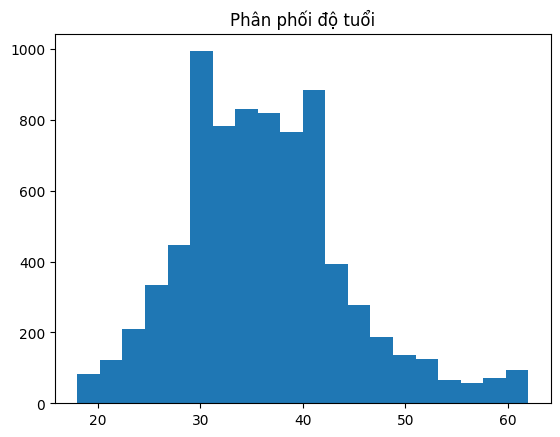


✅ HOÀN THÀNH - ĐÃ LƯU cleaned_final.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. ĐỌC DỮ LIỆU
# ======================
df = pd.read_csv("Bank Customer Churn Prediction.csv")

print("=== 5 dòng đầu ===")
print(df.head())

print("\n=== TÊN CỘT ===")
print(df.columns)


# ======================
# 2. CHUẨN HÓA TÊN CỘT
# ======================
df.columns = df.columns.str.strip().str.lower()

print("\n=== CỘT SAU KHI CHUẨN HÓA ===")
print(df.columns)


# ======================
# 3. XÓA CỘT KHÔNG CẦN
# ======================
cols_drop = ['rownumber', 'customerid', 'surname']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])

print("\n=== Sau khi xóa cột ===")
print(df.head())


# ======================
# 4. XỬ LÝ MISSING
# ======================
print("\n=== Missing trước ===")
print(df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n=== Missing sau ===")
print(df.isnull().sum())


# ======================
# 5. XÓA TRÙNG
# ======================
before = len(df)
df = df.drop_duplicates()
print(f"\nĐã xóa {before - len(df)} dòng trùng")


# ======================
# 6. CHUẨN HÓA TEXT
# ======================
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()

print("\n=== Sau khi chuẩn hóa text ===")
print(df.head())


# ======================
# 7. LOẠI GIÁ TRỊ ÂM
# ======================
for col in df.select_dtypes(include=np.number).columns:
    df = df[df[col] >= 0]

print("\n=== Sau khi loại giá trị âm ===")
print(df.describe())


# ======================
# 8. XỬ LÝ OUTLIERS
# ======================
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in df.select_dtypes(include=np.number).columns:
    df = remove_outliers(df, col)

print("\n=== Sau khi xử lý outliers ===")
print(df.describe())


# ======================
# 9. ENCODE
# ======================
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

if 'geography' in df.columns:
    df = pd.get_dummies(df, columns=['geography'], drop_first=True)

print("\n=== Sau encode ===")
print(df.head())


# ======================
# 10. TRỰC QUAN (EDA)
# ======================

# 10.1 SỐ LƯỢNG CHURN
if 'exited' in df.columns:
    print("\n=== Số lượng churn ===")
    print(df['exited'].value_counts())

    df['exited'].value_counts().plot(kind='bar')
    plt.title("Số lượng khách hàng rời bỏ")
    plt.show()


# 10.2 PHÂN PHỐI TUỔI
if 'age' in df.columns:
    plt.hist(df['age'], bins=20)
    plt.title("Phân phối độ tuổi")
    plt.show()


# 10.3 BALANCE VS CHURN
if 'balance' in df.columns and 'exited' in df.columns:
    df.boxplot(column='balance', by='exited')
    plt.title("Balance vs Churn")
    plt.show()


# ======================
# 11. LƯU FILE
# ======================
df.to_csv("cleaned_final.csv", index=False)

print("\n✅ HOÀN THÀNH - ĐÃ LƯU cleaned_final.csv")